# Integrated Urban Noise Classification & Event Detection Pipeline

This notebook combines the complete pipeline for urban noise classification:

1. **Pre-processing**: Chunk media files and analyze noise levels
2. **Audio Inference**: Classify audio chunks using fine-tuned SpeechBrain model
3. **Video Inference**: Detect objects and construction sites using dual YOLO models
4. **Event Classification**: Classify events based on Indian Noise Pollution Rules

## Pipeline Overview

```
Input Media (MP4)
    ↓
[Pre-processing] → Audio/Video chunks + Noise analysis
    ↓
[Audio Inference] → Audio classifications
    ↓
[Video Inference] → Object detections + Construction site detection
    ↓
[Event Classification] → Zone-based compliance analysis
    ↓
Output: Classified events with violation details
```

## Indian Noise Pollution Rules

| Zone | Day Limit (6am-10pm) | Night Limit (10pm-6am) |
|------|---------------------|------------------------|
| Residential | ≤ 55 dB(A) | ≤ 45 dB(A) |
| Industrial | ≤ 75 dB(A) | ≤ 70 dB(A) |
| Silence | ≤ 50 dB(A) | ≤ 40 dB(A) |
| Commercial | ≤ 65 dB(A) | ≤ 55 dB(A) |

## 1. Setup and Imports

In [18]:
import os
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Add module paths
sys.path.append(str(Path.cwd().parent / "pre_inference"))
sys.path.append(str(Path.cwd().parent / "audio-classifier" / "speechbrain-classifier"))
sys.path.append(str(Path.cwd().parent / "image-classifier" / "video_inference"))

# Import integrated pipeline
from integrated_inference import IntegratedInferencePipeline
from event_classifier import NoiseZone, ViolationType, EventClassifier
from event_storage import EventStorage

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All modules imported successfully!")

✅ All modules imported successfully!


## 2. Configuration

Configure all pipeline parameters in one place.

In [19]:
# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Input/Output Directories
    'input_dir': '../pre_inference/input_data_buffer',
    'preprocessing_output_dir': '../pre_inference/processed_media',
    'event_output_dir': './output/events',
    
    # Pre-processing Settings
    'chunk_duration': 10.0,  # seconds
    
    # Audio Inference Settings
    'audio_pretrained_model': '../audio-classifier/speechbrain-classifier/pretrained_urbansound8k',
    'audio_finetuned_weights': '../audio-classifier/speechbrain-classifier/fine_tuned_urbansound8k_8class.pth',
    'audio_num_classes': 8,
    'audio_class_names': [
        "crowd-noise",
        "generator",
        "motorvehicle-horn",
        "mobile-music",
        "community-radio",
        "construction-site",
        "motorvehicle-siren",
        "car-alarm"
    ],
    'audio_sample_rate': 16000,
    'audio_max_length': 160000,  # 10 seconds at 16kHz
    'audio_batch_size': 8,
    
    # Video Inference Settings
    'yolo_standard_model': '../image-classifier/YOLOv8/yolov8n.pt',
    'yolo_mocs_model': '../image-classifier/YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt',
    'yolo_conf_threshold': 0.5,
    'frame_skip': 30,  # Process every 30th frame
    'aggregation_method': 'weighted_average',
    'min_detection_percentage': 10.0,
    'construction_threshold': 0.7,
    'device': 'cuda',  # 'cuda' or 'cpu'
    
    # Event Classification Settings
    'default_zone': NoiseZone.RESIDENTIAL,  # RESIDENTIAL, INDUSTRIAL, SILENCE, COMMERCIAL
    'base_timestamp': datetime.now().replace(hour=12, minute=0, second=0, microsecond=0),
    
    # Processing Flags (set to True to skip steps and use existing data)
    'skip_preprocessing': False,
    'skip_audio_inference': False,
    'skip_video_inference': False,
}

# Print configuration
print("Configuration:")
print("=" * 80)
for category in ['Input/Output Directories', 'Pre-processing Settings', 
                 'Audio Inference Settings', 'Video Inference Settings',
                 'Event Classification Settings', 'Processing Flags']:
    print(f"\n{category}:")
    
print(f"  Input Directory: {CONFIG['input_dir']}")
print(f"  Preprocessing Output: {CONFIG['preprocessing_output_dir']}")
print(f"  Event Output: {CONFIG['event_output_dir']}")
print(f"\n  Chunk Duration: {CONFIG['chunk_duration']} seconds")
print(f"  Audio Classes: {CONFIG['audio_num_classes']}")
print(f"  YOLO Confidence: {CONFIG['yolo_conf_threshold']}")
print(f"  Frame Skip: {CONFIG['frame_skip']}")
print(f"  Default Zone: {CONFIG['default_zone'].value}")
print(f"\n  Skip Preprocessing: {CONFIG['skip_preprocessing']}")
print(f"  Skip Audio Inference: {CONFIG['skip_audio_inference']}")
print(f"  Skip Video Inference: {CONFIG['skip_video_inference']}")
print("=" * 80)

Configuration:

Input/Output Directories:

Pre-processing Settings:

Audio Inference Settings:

Video Inference Settings:

Event Classification Settings:

Processing Flags:
  Input Directory: ../pre_inference/input_data_buffer
  Preprocessing Output: ../pre_inference/processed_media
  Event Output: ./output/events

  Chunk Duration: 10.0 seconds
  Audio Classes: 8
  YOLO Confidence: 0.5
  Frame Skip: 30
  Default Zone: residential

  Skip Preprocessing: False
  Skip Audio Inference: False
  Skip Video Inference: False


## 3. Initialize Pipeline

Create the integrated pipeline with all configurations.

In [20]:
# Initialize integrated pipeline
pipeline = IntegratedInferencePipeline(
    # Pre-processing
    input_dir=CONFIG['input_dir'],
    preprocessing_output_dir=CONFIG['preprocessing_output_dir'],
    chunk_duration=CONFIG['chunk_duration'],
    
    # Audio inference
    audio_pretrained_model=CONFIG['audio_pretrained_model'],
    audio_finetuned_weights=CONFIG['audio_finetuned_weights'],
    audio_num_classes=CONFIG['audio_num_classes'],
    audio_class_names=CONFIG['audio_class_names'],
    audio_sample_rate=CONFIG['audio_sample_rate'],
    audio_max_length=CONFIG['audio_max_length'],
    audio_batch_size=CONFIG['audio_batch_size'],
    
    # Video inference
    yolo_standard_model=CONFIG['yolo_standard_model'],
    yolo_mocs_model=CONFIG['yolo_mocs_model'],
    yolo_conf_threshold=CONFIG['yolo_conf_threshold'],
    frame_skip=CONFIG['frame_skip'],
    aggregation_method=CONFIG['aggregation_method'],
    min_detection_percentage=CONFIG['min_detection_percentage'],
    construction_threshold=CONFIG['construction_threshold'],
    device=CONFIG['device'],
    
    # Event classification
    default_zone=CONFIG['default_zone'],
    event_output_dir=CONFIG['event_output_dir'],
    
    # Processing flags
    skip_preprocessing=CONFIG['skip_preprocessing'],
    skip_audio_inference=CONFIG['skip_audio_inference'],
    skip_video_inference=CONFIG['skip_video_inference']
)

print("✅ Pipeline initialized successfully!")
print(f"   Event Storage: {pipeline.event_storage}")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at 'd:\Projects\UrbanNoiseClassifier\project\inference\..\audio-classifier\speechbrain-classifier\pretrained_urbansound8k\hyperparams.yaml'
DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in ..\audio-classifier\speechbrain-classifier\pretrained_urbansound8k.
D:\Projects\UrbanNoiseClassifier\project\audio-classifier\speechbrain-classifier\speechbrain\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at 'd:\Projects\UrbanNoiseClassifier\project\inference\..\audio-classifier\speechbrain-classifier\pretrained_urbansound8k\embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_tran

✅ Pipeline initialized successfully!
   Event Storage: EventStorage(total=0, compliant=0, violations=0)


## 4. Run Complete Pipeline

Execute all steps: preprocessing → audio inference → video inference → event classification.

In [21]:
# Run the complete pipeline
classified_events, event_storage = pipeline.run_full_pipeline(
    zone=CONFIG['default_zone'],
    base_timestamp=CONFIG['base_timestamp'],
    save_results=True
)

print(f"\n{'='*80}")
print(f"✅ Pipeline execution complete!")
print(f"   Total events classified: {len(classified_events)}")
print(f"   Events stored: {len(event_storage)}")
print(f"{'='*80}")

# Show performance metrics
pipeline.print_performance_report()


🚀 STARTING INTEGRATED INFERENCE PIPELINE
🔄 Starting preprocessing...

INTEGRATED MEDIA PROCESSING PIPELINE
Files to process: 1
Chunk duration: 10.0s
Audio format: wav

Processing: test_clip_1.mp4

[1/4] Separating audio and video...
Extracting audio from test_clip_1.mp4...
Extracting video from test_clip_1.mp4...
Extracting video from test_clip_1.mp4...
✓ Successfully processed test_clip_1.mp4

[2/4] Chunking into 10.0s segments...
Chunking test_clip_1...
✓ Successfully processed test_clip_1.mp4

[2/4] Chunking into 10.0s segments...
Chunking test_clip_1...
  Created 193 audio chunks and 193 video chunks

[3/4] Analyzing audio chunks (A-weighted noise levels)...
  Created 193 audio chunks and 193 video chunks

[3/4] Analyzing audio chunks (A-weighted noise levels)...


d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)



[4/4] Creating metadata...

✓ Successfully processed test_clip_1.mp4
  - Created 193 audio chunks
  - Created 193 video chunks
  - Analyzed 193 audio segments

PROCESSING COMPLETE
Successful: 1
Failed: 0
Master index: ..\pre_inference\processed_media\chunk_metadata\master_chunk_index.json

✅ Preprocessing complete: 1 files processed in 84.23s (1.40 min)
🎵 Starting audio inference on: ..\pre_inference\processed_media\audio_chunks
Found 193 audio files in ..\pre_inference\processed_media\audio_chunks


Processing batches:   0%|          | 0/25 [00:00<?, ?it/s]d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: 

✅ Saved CSV results to: output\events\audio_inference\inference_results_20251102_013925.csv
✅ Saved probability vectors to: output\events\audio_inference\probability_vectors_20251102_013925.npy
✅ Saved metadata to: output\events\audio_inference\metadata_20251102_013925.json
✅ Audio inference complete: 193 chunks processed in 3.87s (0.06 min)
🎬 Starting video inference on: ..\pre_inference\processed_media\video_chunks
Found 193 video chunks
  Processing 1/193: test_clip_1_chunk_0000.mp4


...

  Processing 180/193: test_clip_1_chunk_0179.mp4


INFO:dual_yolo_inference:Processing frame 150
INFO:dual_yolo_inference:Processing frame 180
INFO:dual_yolo_inference:Processing frame 180
INFO:video_frame_extractor:Video info for test_clip_1_chunk_0179.mp4: {'fps': 30.0, 'frame_count': 182, 'width': 852, 'height': 480, 'duration': 6.066666666666666, 'codec': 875967080}
INFO:output_fusion:Fusing results for ..\pre_inference\processed_media\video_chunks\test_clip_1_chunk_0179.mp4 (7 frames)
INFO:output_fusion:Construction site: True (confidence: 100.00%)
INFO:output_fusion:Standard detections: 1 unique classes
INFO:output_fusion:MOCS detections: 2 unique classes
INFO:video_frame_extractor:Video info for test_clip_1_chunk_0179.mp4: {'fps': 30.0, 'frame_count': 182, 'width': 852, 'height': 480, 'duration': 6.066666666666666, 'codec': 875967080}
INFO:output_fusion:Fusing results for ..\pre_inference\processed_media\video_chunks\test_clip_1_chunk_0179.mp4 (7 frames)
INFO:output_fusion:Construction site: True (confidence: 100.00%)
INFO:outpu

  Processing 190/193: test_clip_1_chunk_0189.mp4


INFO:dual_yolo_inference:Processing frame 180
INFO:dual_yolo_inference:Processing frame 210
INFO:dual_yolo_inference:Processing frame 210
INFO:dual_yolo_inference:Processing frame 240
INFO:dual_yolo_inference:Processing frame 240
INFO:video_frame_extractor:Video info for test_clip_1_chunk_0189.mp4: {'fps': 30.0, 'frame_count': 264, 'width': 852, 'height': 480, 'duration': 8.8, 'codec': 875967080}
INFO:output_fusion:Fusing results for ..\pre_inference\processed_media\video_chunks\test_clip_1_chunk_0189.mp4 (9 frames)
INFO:output_fusion:Construction site: False (confidence: 0.00%)
INFO:output_fusion:Standard detections: 0 unique classes
INFO:output_fusion:MOCS detections: 0 unique classes
INFO:video_frame_extractor:Video info for test_clip_1_chunk_0189.mp4: {'fps': 30.0, 'frame_count': 264, 'width': 852, 'height': 480, 'duration': 8.8, 'codec': 875967080}
INFO:output_fusion:Fusing results for ..\pre_inference\processed_media\video_chunks\test_clip_1_chunk_0189.mp4 (9 frames)
INFO:output_

  Processing 193/193: test_clip_1_chunk_0192.mp4
✅ Video inference complete: 193 chunks processed in 71.15s (1.19 min)
📊 Loading noise analysis summaries...
🔗 Matching audio and video chunks...
  ⚠️  Skipping test_clip_1_chunk_0190: invalid noise level (-inf)
  ⚠️  Skipping test_clip_1_chunk_0191: invalid noise level (-inf)
  ⚠️  Skipping test_clip_1_chunk_0192: invalid noise level (-inf)
✅ Matched 190 chunks in 0.01s
   ⚠️  Filtered out 3 chunks with invalid noise levels
🏷️  Classifying events...
✅ Classified 190 events in 0.00s
💾 Storing classified events...
📁 Saving results...
  ✓ Events JSON: output\events\json\events_20251102_014036.json
  ✓ Events CSV: output\events\csv\events_20251102_014036.csv
  ✓ Detailed CSV: output\events\csv\events_detailed_20251102_014036.csv
  ✓ Violations JSON: output\events\json\violations_20251102_014036.json
  ✓ Summary Report: output\events\summaries\summary_20251102_014036.json

✅ PIPELINE COMPLETE
Total events: 190
Compliant: 9
Violations: 181

⏱️

## 4.1. Performance Analysis

Visualize how time was spent across different pipeline stages.

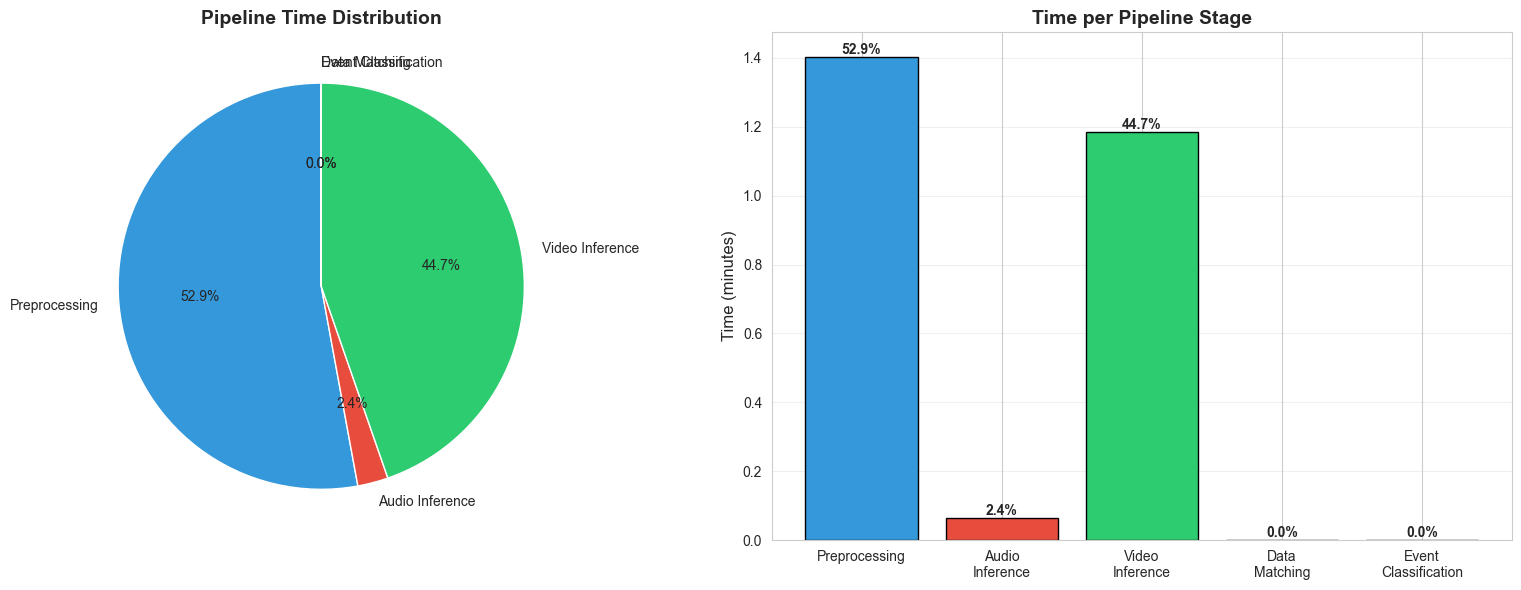


📊 PERFORMANCE SUMMARY
Total Pipeline Time: 159.30s (2.65 minutes)

Audio Inference:
  • Chunks processed: 193
  • Time per chunk: 0.020s
  • Throughput: 2989.0 chunks/min

Video Inference:
  • Chunks processed: 193
  • Time per chunk: 0.369s
  • Throughput: 162.8 chunks/min

Event Classification:
  • Events classified: 190
  • Time per event: 0.0000s
  • Classification rate: 103294.6 events/sec


In [22]:
# Get performance metrics
metrics = pipeline.get_performance_report()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Time distribution pie chart
ax1 = axes[0]
stages = []
durations = []
colors_perf = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (stage, color) in enumerate(zip(
    ['preprocessing', 'audio_inference', 'video_inference', 'data_matching', 'event_classification'],
    colors_perf
)):
    if metrics[stage]['duration'] > 0:
        stages.append(stage.replace('_', ' ').title())
        durations.append(metrics[stage]['duration'])

ax1.pie(durations, labels=stages, autopct='%1.1f%%', colors=colors_perf[:len(stages)], startangle=90)
ax1.set_title('Pipeline Time Distribution', fontsize=14, fontweight='bold')

# 2. Time comparison bar chart
ax2 = axes[1]
stage_names = []
stage_times = []
stage_percentages = []

for stage in ['preprocessing', 'audio_inference', 'video_inference', 'data_matching', 'event_classification']:
    if metrics[stage]['duration'] > 0:
        stage_names.append(stage.replace('_', '\n').title())
        stage_times.append(metrics[stage]['duration'] / 60)  # Convert to minutes
        stage_percentages.append(metrics[stage].get('percentage', 0))

bars = ax2.bar(stage_names, stage_times, color=colors_perf[:len(stage_names)], edgecolor='black')
ax2.set_ylabel('Time (minutes)', fontsize=12)
ax2.set_title('Time per Pipeline Stage', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar, pct in zip(bars, stage_percentages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{pct:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print performance summary
print("\n📊 PERFORMANCE SUMMARY")
print("=" * 80)
total_time = metrics['total_pipeline']['duration']
print(f"Total Pipeline Time: {total_time:.2f}s ({total_time/60:.2f} minutes)")

if metrics['audio_inference']['chunks_processed'] > 0:
    print(f"\nAudio Inference:")
    print(f"  • Chunks processed: {metrics['audio_inference']['chunks_processed']}")
    print(f"  • Time per chunk: {metrics['audio_inference'].get('time_per_chunk', 0):.3f}s")
    print(f"  • Throughput: {metrics['audio_inference']['chunks_processed'] / (metrics['audio_inference']['duration'] / 60):.1f} chunks/min")

if metrics['video_inference']['chunks_processed'] > 0:
    print(f"\nVideo Inference:")
    print(f"  • Chunks processed: {metrics['video_inference']['chunks_processed']}")
    print(f"  • Time per chunk: {metrics['video_inference'].get('time_per_chunk', 0):.3f}s")
    print(f"  • Throughput: {metrics['video_inference']['chunks_processed'] / (metrics['video_inference']['duration'] / 60):.1f} chunks/min")

if metrics['event_classification']['events_classified'] > 0:
    print(f"\nEvent Classification:")
    print(f"  • Events classified: {metrics['event_classification']['events_classified']}")
    print(f"  • Time per event: {metrics['event_classification'].get('time_per_event', 0):.4f}s")
    print(f"  • Classification rate: {metrics['event_classification']['events_classified'] / metrics['event_classification']['duration']:.1f} events/sec")

print("=" * 80)


## 5. Event Analysis - Overview

Analyze the classified events and compliance status.

In [23]:
# Get summary statistics
total_events = len(classified_events)

# Data quality check
if total_events == 0:
    print("⚠️  WARNING: No events to analyze!")
    print("   This may be because all chunks had invalid noise levels.")
    print("   Check the pre-processing noise analysis step.")
else:
    compliant_events = sum(1 for e in classified_events if e.is_compliant)
    violation_events = total_events - compliant_events

    print("📊 EVENT ANALYSIS OVERVIEW")
    print("=" * 80)
    print(f"Total Events: {total_events}")
    print(f"Compliant Events: {compliant_events} ({compliant_events/total_events*100:.1f}%)")
    print(f"Violation Events: {violation_events} ({violation_events/total_events*100:.1f}%)")
    print("=" * 80)

    # Severity breakdown
    severity_counts = {}
    for event in classified_events:
        severity_counts[event.severity] = severity_counts.get(event.severity, 0) + 1

    print("\nSeverity Breakdown:")
    for severity in ['compliant', 'minor', 'moderate', 'severe']:
        count = severity_counts.get(severity, 0)
        print(f"  {severity.capitalize()}: {count} ({count/total_events*100:.1f}%)")

    # Violation type breakdown
    violation_type_counts = {}
    for event in classified_events:
        for violation in event.violations:
            if violation != ViolationType.NO_VIOLATION:
                violation_type_counts[violation.value] = violation_type_counts.get(violation.value, 0) + 1

    print("\nViolation Types:")
    for v_type, count in sorted(violation_type_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {v_type}: {count}")

    print("=" * 80)


📊 EVENT ANALYSIS OVERVIEW
Total Events: 190
Compliant Events: 9 (4.7%)
Violation Events: 181 (95.3%)

Severity Breakdown:
  Compliant: 9 (4.7%)
  Minor: 88 (46.3%)
  Moderate: 73 (38.4%)
  Severe: 20 (10.5%)

Violation Types:
  ambient_exceeded: 181


## 6. Visualize Event Statistics

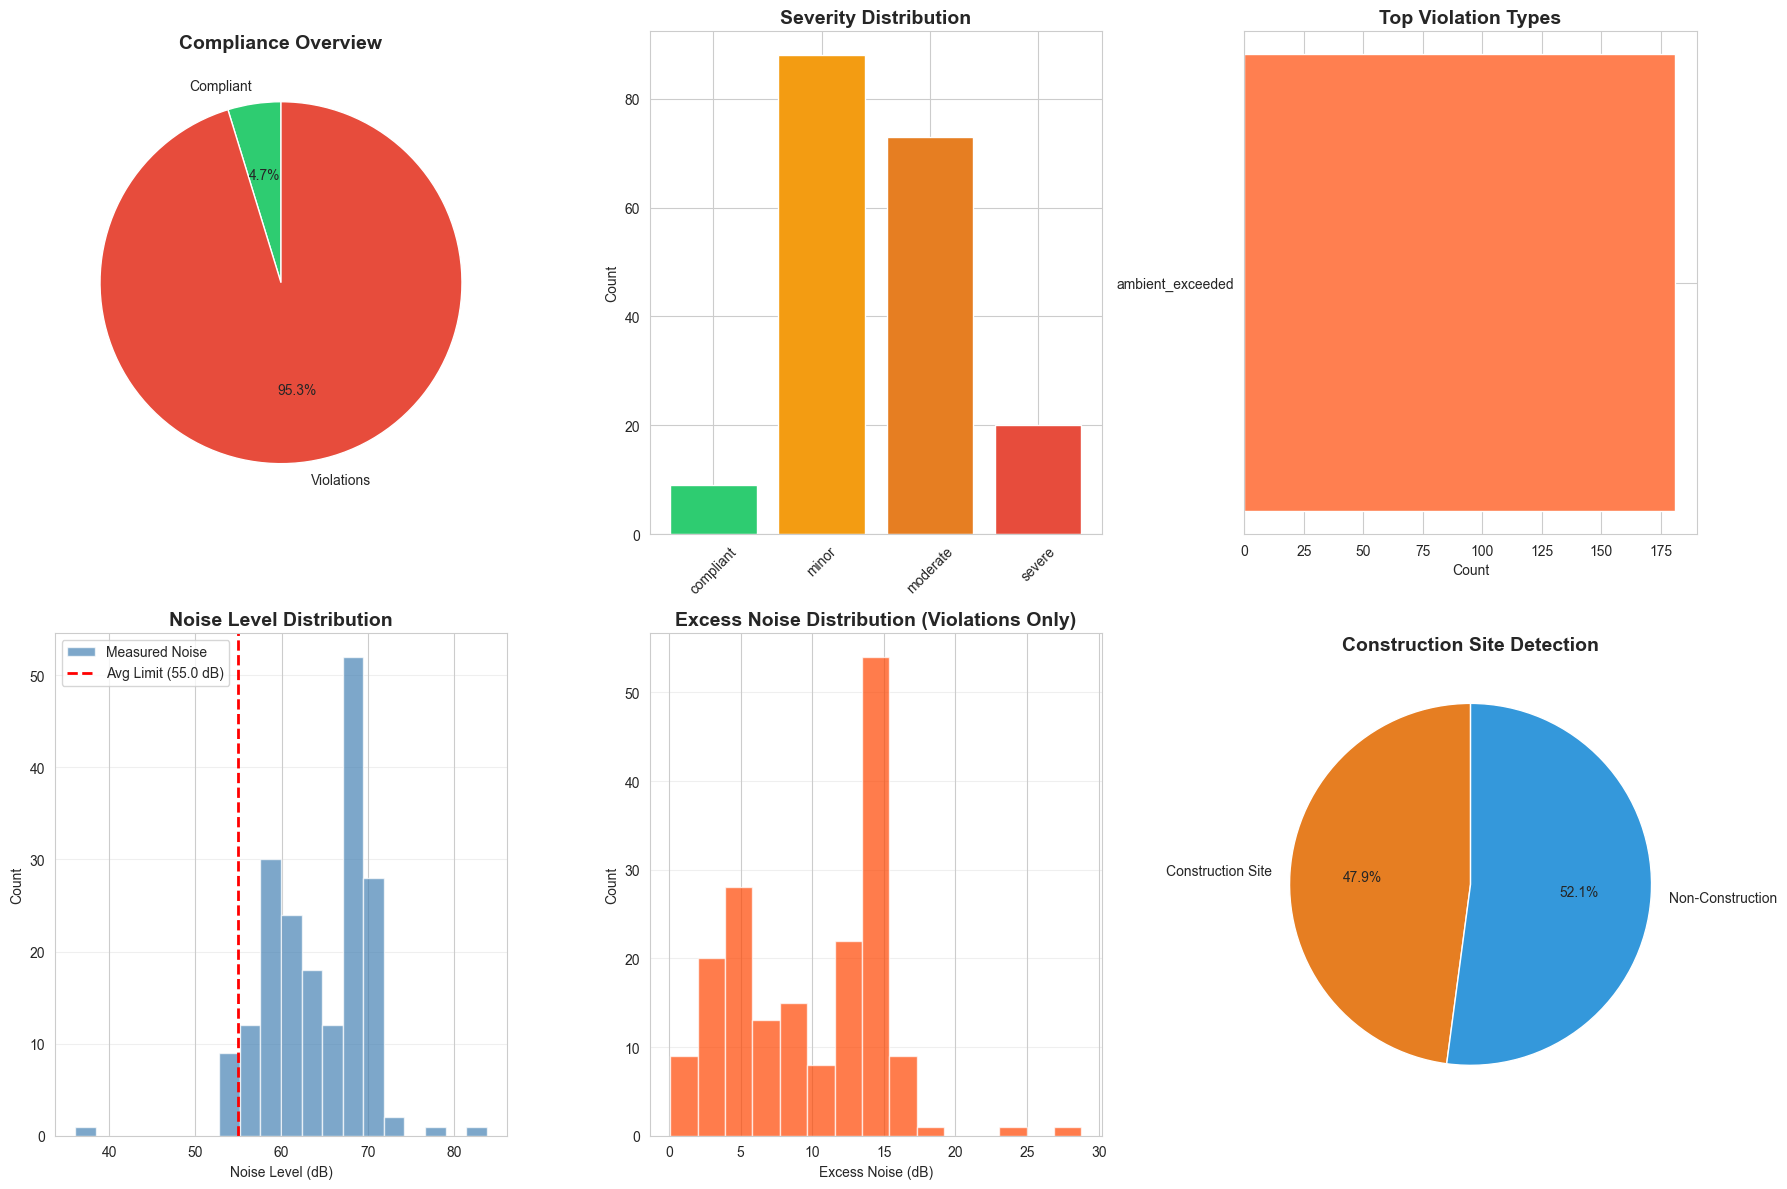

✅ Visualizations generated


In [24]:
# Create comprehensive visualizations
if total_events == 0:
    print("⚠️  No events to visualize")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Compliance pie chart
    ax1 = axes[0, 0]
    compliance_data = [compliant_events, violation_events]
    colors = ['#2ecc71', '#e74c3c']
    ax1.pie(compliance_data, labels=['Compliant', 'Violations'], autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax1.set_title('Compliance Overview', fontsize=14, fontweight='bold')

    # 2. Severity distribution
    ax2 = axes[0, 1]
    severity_labels = list(severity_counts.keys())
    severity_values = list(severity_counts.values())
    colors_severity = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    ax2.bar(severity_labels, severity_values, color=colors_severity[:len(severity_labels)])
    ax2.set_ylabel('Count')
    ax2.set_title('Severity Distribution', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)

    # 3. Violation types
    ax3 = axes[0, 2]
    if violation_type_counts:
        v_types = list(violation_type_counts.keys())[:6]  # Top 6
        v_counts = [violation_type_counts[vt] for vt in v_types]
        ax3.barh(v_types, v_counts, color='coral')
        ax3.set_xlabel('Count')
        ax3.set_title('Top Violation Types', fontsize=14, fontweight='bold')
        ax3.invert_yaxis()
    else:
        ax3.text(0.5, 0.5, 'No violations', ha='center', va='center', transform=ax3.transAxes)

    # 4. Noise level distribution (already filtered at source, but double-check for safety)
    ax4 = axes[1, 0]
    noise_levels = [e.noise_level_db for e in classified_events if np.isfinite(e.noise_level_db)]
    ambient_limits = [e.ambient_limit_db for e in classified_events if np.isfinite(e.noise_level_db)]

    if noise_levels:
        ax4.hist(noise_levels, bins=20, alpha=0.7, label='Measured Noise', color='steelblue')
        if ambient_limits:
            ax4.axvline(np.mean(ambient_limits), color='red', linestyle='--', 
                        linewidth=2, label=f'Avg Limit ({np.mean(ambient_limits):.1f} dB)')
        ax4.set_xlabel('Noise Level (dB)')
        ax4.set_ylabel('Count')
        ax4.set_title('Noise Level Distribution', fontsize=14, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No valid noise level data', 
                 ha='center', va='center', transform=ax4.transAxes)

    # 5. Excess noise for violations
    ax5 = axes[1, 1]
    # Filter out invalid excess noise values (safety check)
    excess_noise = [e.excess_db for e in classified_events 
                    if e.noise_exceeded and np.isfinite(e.excess_db)]
    if excess_noise:
        ax5.hist(excess_noise, bins=15, color='orangered', alpha=0.7)
        ax5.set_xlabel('Excess Noise (dB)')
        ax5.set_ylabel('Count')
        ax5.set_title('Excess Noise Distribution (Violations Only)', fontsize=14, fontweight='bold')
        ax5.grid(axis='y', alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No excess noise violations', 
                 ha='center', va='center', transform=ax5.transAxes)

    # 6. Construction site detections
    ax6 = axes[1, 2]
    construction_count = sum(1 for e in classified_events if e.is_construction_site)
    non_construction_count = total_events - construction_count
    ax6.pie([construction_count, non_construction_count], 
            labels=['Construction Site', 'Non-Construction'],
            autopct='%1.1f%%', colors=['#e67e22', '#3498db'], startangle=90)
    ax6.set_title('Construction Site Detection', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("✅ Visualizations generated")


## 7. Detailed Event Inspection

Examine individual events in detail.

In [25]:
# Show sample of violation events
violations = event_storage.get_violations_only()

print("🚨 SAMPLE VIOLATION EVENTS")
print("=" * 80)

for i, event in enumerate(violations[:5], 1):  # Show first 5 violations
    print(f"\nEvent {i}: {event.event_id}")
    print(f"  Timestamp: {event.timestamp.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Zone: {event.zone.value} | Time: {event.time_of_day.value}")
    print(f"  Noise: {event.noise_level_db:.1f} dB (Limit: {event.ambient_limit_db:.1f} dB)")
    print(f"  Excess: {event.excess_db:.1f} dB")
    print(f"  Severity: {event.severity.upper()}")
    print(f"  Violations: {', '.join([v.value for v in event.violations])}")
    
    # Show top audio detection
    if event.audio_classes:
        top_audio = max(event.audio_classes.items(), key=lambda x: x[1])
        print(f"  Top Audio: {top_audio[0]} ({top_audio[1]:.2%})")
    
    # Show construction detection
    if event.is_construction_site:
        print(f"  Construction Site: Yes ({event.construction_confidence:.2%})")
    
    # Show recommendations
    print(f"  Recommendations:")
    for rec in event.recommendations:
        print(f"    - {rec}")
    
    print("-" * 80)

if len(violations) == 0:
    print("✅ No violations detected - all events are compliant!")
else:
    print(f"\nTotal violations: {len(violations)}")
print("=" * 80)

🚨 SAMPLE VIOLATION EVENTS

Event 1: test_clip_1_chunk_0001
  Timestamp: 2025-11-02 12:00:10
  Zone: residential | Time: day
  Noise: 58.8 dB (Limit: 55.0 dB)
  Excess: 3.8 dB
  Severity: MINOR
  Violations: ambient_exceeded
  Top Audio: motorvehicle-horn (70.52%)
  Recommendations:
    - Reduce ambient noise by 3.8 dB to comply with residential zone daytime limits
--------------------------------------------------------------------------------

Event 2: test_clip_1_chunk_0002
  Timestamp: 2025-11-02 12:00:20
  Zone: residential | Time: day
  Noise: 59.9 dB (Limit: 55.0 dB)
  Excess: 4.9 dB
  Severity: MINOR
  Violations: ambient_exceeded
  Top Audio: motorvehicle-horn (49.58%)
  Recommendations:
    - Reduce ambient noise by 4.9 dB to comply with residential zone daytime limits
--------------------------------------------------------------------------------

Event 3: test_clip_1_chunk_0003
  Timestamp: 2025-11-02 12:00:30
  Zone: residential | Time: day
  Noise: 61.3 dB (Limit: 55.0 dB

## 8. Zone and Time Analysis

In [26]:
# Analyze by zone and time of day
zone_time_analysis = {}

for event in classified_events:
    zone = event.zone.value
    time_of_day = event.time_of_day.value
    
    key = f"{zone}_{time_of_day}"
    
    if key not in zone_time_analysis:
        zone_time_analysis[key] = {
            'total': 0,
            'compliant': 0,
            'violations': 0,
            'avg_noise': 0,
            'noise_levels': []
        }
    
    zone_time_analysis[key]['total'] += 1
    zone_time_analysis[key]['noise_levels'].append(event.noise_level_db)
    
    if event.is_compliant:
        zone_time_analysis[key]['compliant'] += 1
    else:
        zone_time_analysis[key]['violations'] += 1

# Calculate averages
for key in zone_time_analysis:
    data = zone_time_analysis[key]
    data['avg_noise'] = np.mean(data['noise_levels'])

# Display analysis
print("📍 ZONE AND TIME ANALYSIS")
print("=" * 80)
print(f"{'Zone & Time':<25} {'Total':<8} {'Compliant':<10} {'Violations':<12} {'Avg Noise':<12}")
print("-" * 80)

for key, data in sorted(zone_time_analysis.items()):
    zone, time = key.split('_')
    compliance_pct = data['compliant'] / data['total'] * 100 if data['total'] > 0 else 0
    print(f"{zone} ({time}):<25 {data['total']:<8} "
          f"{data['compliant']:<10} {data['violations']:<12} {data['avg_noise']:.1f} dB")

print("=" * 80)

📍 ZONE AND TIME ANALYSIS
Zone & Time               Total    Compliant  Violations   Avg Noise   
--------------------------------------------------------------------------------
residential (day):<25 190      9          181          64.2 dB


## 9. Audio Classification Analysis

🎵 AUDIO CLASSIFICATION SUMMARY
Audio Class                    Count      Percentage  
--------------------------------------------------------------------------------
motorvehicle-horn              59         31.1%
generator                      56         29.5%
construction-site              38         20.0%
crowd-noise                    26         13.7%
motorvehicle-siren             8          4.2%
mobile-music                   2          1.1%


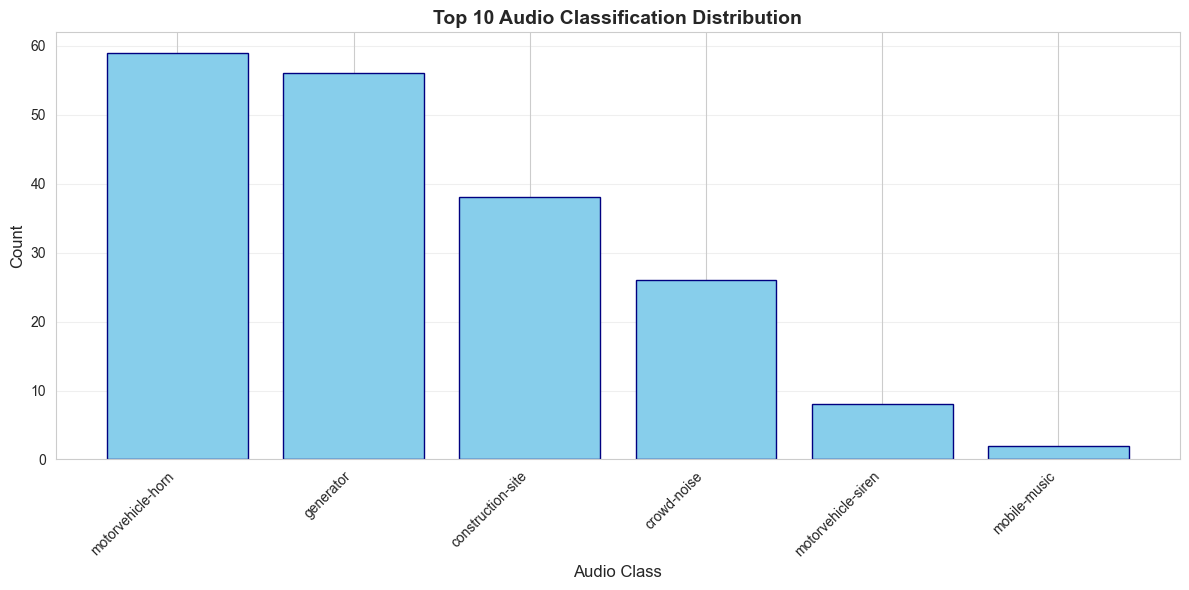

In [27]:
# Analyze audio classifications
audio_class_counts = {}
for event in classified_events:
    for audio_class, confidence in event.audio_classes.items():
        if confidence > 0.3:  # Only count confident detections
            audio_class_counts[audio_class] = audio_class_counts.get(audio_class, 0) + 1

print("🎵 AUDIO CLASSIFICATION SUMMARY")
print("=" * 80)
print(f"{'Audio Class':<30} {'Count':<10} {'Percentage':<12}")
print("-" * 80)

# Show top classes only
for audio_class, count in sorted(audio_class_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    percentage = count / total_events * 100
    print(f"{audio_class:<30} {count:<10} {percentage:.1f}%")

if len(audio_class_counts) > 10:
    remaining = len(audio_class_counts) - 10
    print(f"\n... and {remaining} more classes (showing top 10)")

print("=" * 80)

# Visualize audio class distribution
if audio_class_counts:
    plt.figure(figsize=(12, 6))
    top_classes = sorted(audio_class_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    classes, counts = zip(*top_classes)
    
    plt.bar(classes, counts, color='skyblue', edgecolor='navy')
    plt.xlabel('Audio Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Top 10 Audio Classification Distribution', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 10. Video Detection Analysis

🎬 VIDEO DETECTION SUMMARY
Video Class                    Count      Percentage  
--------------------------------------------------------------------------------
truck                          111        58.4%
car                            107        56.3%
person                         76         40.0%
motorcycle                     53         27.9%
bus                            21         11.1%
airplane                       21         11.1%
bicycle                        8          4.2%
umbrella                       6          3.2%
backpack                       2          1.1%
train                          2          1.1%
fire hydrant                   1          0.5%
suitcase                       1          0.5%
horse                          1          0.5%
bench                          1          0.5%
traffic light                  1          0.5%


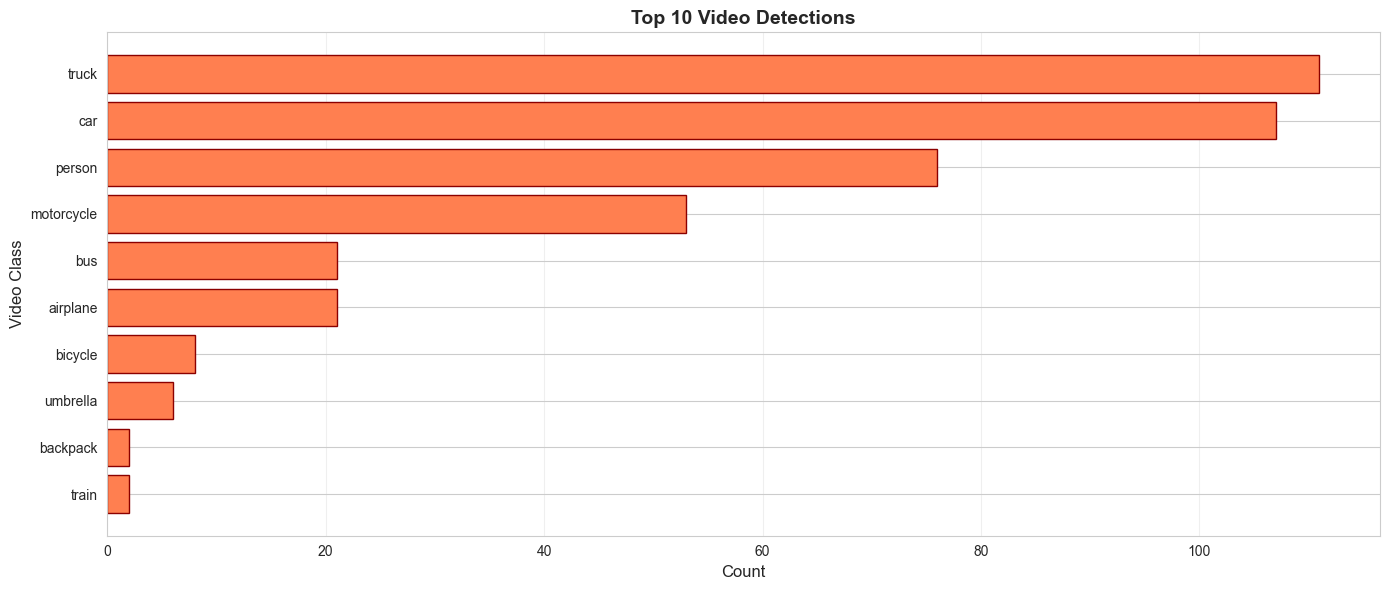

In [28]:
# Analyze video detections
video_class_counts = {}
for event in classified_events:
    for video_class, confidence in event.video_classes.items():
        if confidence > 0.3:  # Only count confident detections
            video_class_counts[video_class] = video_class_counts.get(video_class, 0) + 1

print("🎬 VIDEO DETECTION SUMMARY")
print("=" * 80)

if video_class_counts:
    print(f"{'Video Class':<30} {'Count':<10} {'Percentage':<12}")
    print("-" * 80)
    
    for video_class, count in sorted(video_class_counts.items(), key=lambda x: x[1], reverse=True)[:15]:
        percentage = count / total_events * 100
        print(f"{video_class:<30} {count:<10} {percentage:.1f}%")
    
    print("=" * 80)
    
    # Visualize top video detections
    plt.figure(figsize=(14, 6))
    top_classes = sorted(video_class_counts.items(), key=lambda x: x[1], reverse=True)[:10]
    classes, counts = zip(*top_classes)
    
    plt.barh(classes, counts, color='coral', edgecolor='darkred')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Video Class', fontsize=12)
    plt.title('Top 10 Video Detections', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No video detections available")
    print("=" * 80)

## 11. Export and Save Results

All results are automatically saved during pipeline execution. Review saved files here.

In [29]:
# List all saved files
output_dir = Path(CONFIG['event_output_dir'])

print("📁 SAVED OUTPUT FILES")
print("=" * 80)

# JSON files
json_dir = output_dir / "json"
if json_dir.exists():
    print("\nJSON Files:")
    for file in sorted(json_dir.glob("*.json")):
        size_kb = file.stat().st_size / 1024
        print(f"  ✓ {file.name} ({size_kb:.1f} KB)")

# CSV files
csv_dir = output_dir / "csv"
if csv_dir.exists():
    print("\nCSV Files:")
    for file in sorted(csv_dir.glob("*.csv")):
        size_kb = file.stat().st_size / 1024
        print(f"  ✓ {file.name} ({size_kb:.1f} KB)")

# Summary files
summary_dir = output_dir / "summaries"
if summary_dir.exists():
    print("\nSummary Reports:")
    for file in sorted(summary_dir.glob("*.json")):
        size_kb = file.stat().st_size / 1024
        print(f"  ✓ {file.name} ({size_kb:.1f} KB)")

print("\n" + "=" * 80)
print(f"All files saved to: {output_dir.absolute()}")
print("=" * 80)

📁 SAVED OUTPUT FILES

JSON Files:
  ✓ events_20251102_003443.json (412.0 KB)
  ✓ events_20251102_004701.json (412.0 KB)
  ✓ events_20251102_005924.json (412.0 KB)
  ✓ events_20251102_011528.json (330.6 KB)
  ✓ events_20251102_012420.json (143.6 KB)
  ✓ events_20251102_013532.json (206.1 KB)
  ✓ events_20251102_014036.json (165.4 KB)
  ✓ violations_20251102_003443.json (412.1 KB)
  ✓ violations_20251102_004701.json (412.1 KB)
  ✓ violations_20251102_005924.json (412.1 KB)
  ✓ violations_20251102_011528.json (317.2 KB)
  ✓ violations_20251102_012420.json (0.2 KB)
  ✓ violations_20251102_013532.json (206.2 KB)
  ✓ violations_20251102_014036.json (158.7 KB)

CSV Files:
  ✓ events_20251102_003443.csv (72.4 KB)
  ✓ events_20251102_004701.csv (72.4 KB)
  ✓ events_20251102_005924.csv (72.4 KB)
  ✓ events_20251102_011528.csv (58.8 KB)
  ✓ events_20251102_012420.csv (29.1 KB)
  ✓ events_20251102_013532.csv (36.3 KB)
  ✓ events_20251102_014036.csv (29.5 KB)
  ✓ events_detailed_20251102_003443.csv

## 12. Load and Analyze Summary Report

In [30]:
# Load the most recent summary report
summary_dir = Path(CONFIG['event_output_dir']) / "summaries"
summary_files = sorted(summary_dir.glob("summary_*.json"))

if summary_files:
    latest_summary = summary_files[-1]
    
    with open(latest_summary, 'r') as f:
        summary = json.load(f)
    
    print("📊 SUMMARY REPORT")
    print("=" * 80)
    print(f"Generated: {summary['generated_at']}")
    print("\nOverview:")
    for key, value in summary['overview'].items():
        print(f"  {key}: {value}")
    
    print("\nViolation Types:")
    for v_type, count in sorted(summary['violation_types'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {v_type}: {count}")
    
    print("\nNoise Statistics:")
    for key, value in summary['noise_statistics'].items():
        print(f"  {key}: {value}")
    
    print("\nConstruction Statistics:")
    for key, value in summary['construction_statistics'].items():
        print(f"  {key}: {value}")
    
    print("=" * 80)
else:
    print("No summary report found")

📊 SUMMARY REPORT
Generated: 2025-11-02T01:40:36.503031

Overview:
  total_events: 190
  compliant_events: 9
  violation_events: 181
  compliance_rate: 4.74

Violation Types:
  ambient_exceeded: 181

Noise Statistics:
  average_noise_db: 64.22
  maximum_noise_db: 83.79
  maximum_excess_db: 28.79

Construction Statistics:
  total_construction_events: 91
  construction_percentage: 47.89


## 13. Custom Event Queries

Filter and analyze specific subsets of events.

In [31]:
# Example custom queries

# 1. Find all severe violations
severe_violations = event_storage.filter_by_severity('severe')
print(f"🚨 Severe Violations: {len(severe_violations)}")
for event in severe_violations[:3]:
    print(f"  - {event.event_id}: {event.noise_level_db:.1f} dB (excess: {event.excess_db:.1f} dB)")

# 2. Find all construction site events
construction_events = [e for e in classified_events if e.is_construction_site]
print(f"\n🏗️ Construction Site Events: {len(construction_events)}")
print(f"   Violations: {sum(1 for e in construction_events if not e.is_compliant)}")
print(f"   Avg Confidence: {np.mean([e.construction_confidence for e in construction_events]):.2%}")

# 3. Find events with horn violations
horn_violations = [
    e for e in classified_events 
    if ViolationType.HORN_PROHIBITED in e.violations
]
print(f"\n📯 Horn Violations: {len(horn_violations)}")

# 4. Find events with multiple violations
multiple_violations = [
    e for e in classified_events 
    if ViolationType.MULTIPLE_VIOLATIONS in e.violations
]
print(f"\n⚠️ Multiple Violations: {len(multiple_violations)}")

# 5. Events exceeding limit by more than 10 dB
high_excess = [e for e in classified_events if e.excess_db > 10]
print(f"\n📈 High Excess (>10 dB): {len(high_excess)}")
if high_excess:
    max_excess_event = max(high_excess, key=lambda e: e.excess_db)
    print(f"   Maximum: {max_excess_event.event_id} - {max_excess_event.excess_db:.1f} dB excess")

print("\n" + "=" * 80)

🚨 Severe Violations: 20
  - test_clip_1_chunk_0012: 78.5 dB (excess: 23.5 dB)
  - test_clip_1_chunk_0013: 83.8 dB (excess: 28.8 dB)
  - test_clip_1_chunk_0071: 71.2 dB (excess: 16.2 dB)

🏗️ Construction Site Events: 91
   Violations: 91
   Avg Confidence: 96.87%

📯 Horn Violations: 0

⚠️ Multiple Violations: 0

📈 High Excess (>10 dB): 93
   Maximum: test_clip_1_chunk_0013 - 28.8 dB excess



## 14. Compare Different Zones

Test classification with different zone settings.

In [32]:
# Compare the same events under different zone regulations
zones_to_test = [NoiseZone.RESIDENTIAL, NoiseZone.INDUSTRIAL, NoiseZone.SILENCE]

comparison_results = {}

for zone in zones_to_test:
    zone_classifier = EventClassifier(zone=zone)
    zone_compliant = 0
    zone_violations = 0
    
    # Re-classify first 10 events under different zone
    for event in classified_events[:10]:
        reclassified = zone_classifier.classify_event(
            event_id=event.event_id,
            timestamp=event.timestamp,
            noise_level_db=event.noise_level_db,
            audio_classes=event.audio_classes,
            video_classes=event.video_classes,
            is_construction_site=event.is_construction_site,
            construction_confidence=event.construction_confidence,
            zone=zone
        )
        
        if reclassified.is_compliant:
            zone_compliant += 1
        else:
            zone_violations += 1
    
    comparison_results[zone.value] = {
        'compliant': zone_compliant,
        'violations': zone_violations,
        'compliance_rate': zone_compliant / 10 * 100
    }

print("🔄 ZONE COMPARISON (First 10 Events)")
print("=" * 80)
print(f"{'Zone':<15} {'Compliant':<12} {'Violations':<12} {'Compliance %':<15}")
print("-" * 80)

for zone_name, results in comparison_results.items():
    print(f"{zone_name:<15} {results['compliant']:<12} "
          f"{results['violations']:<12} {results['compliance_rate']:.1f}%")

print("=" * 80)
print("\n💡 Notice how the same events have different compliance status")
print("   depending on the zone regulations!")

🔄 ZONE COMPARISON (First 10 Events)
Zone            Compliant    Violations   Compliance %   
--------------------------------------------------------------------------------
residential     2            8            20.0%
industrial      10           0            100.0%
silence         0            10           0.0%

💡 Notice how the same events have different compliance status
   depending on the zone regulations!


## 15. Timeline Visualization

Visualize events over time (simulated timeline based on chunk order).

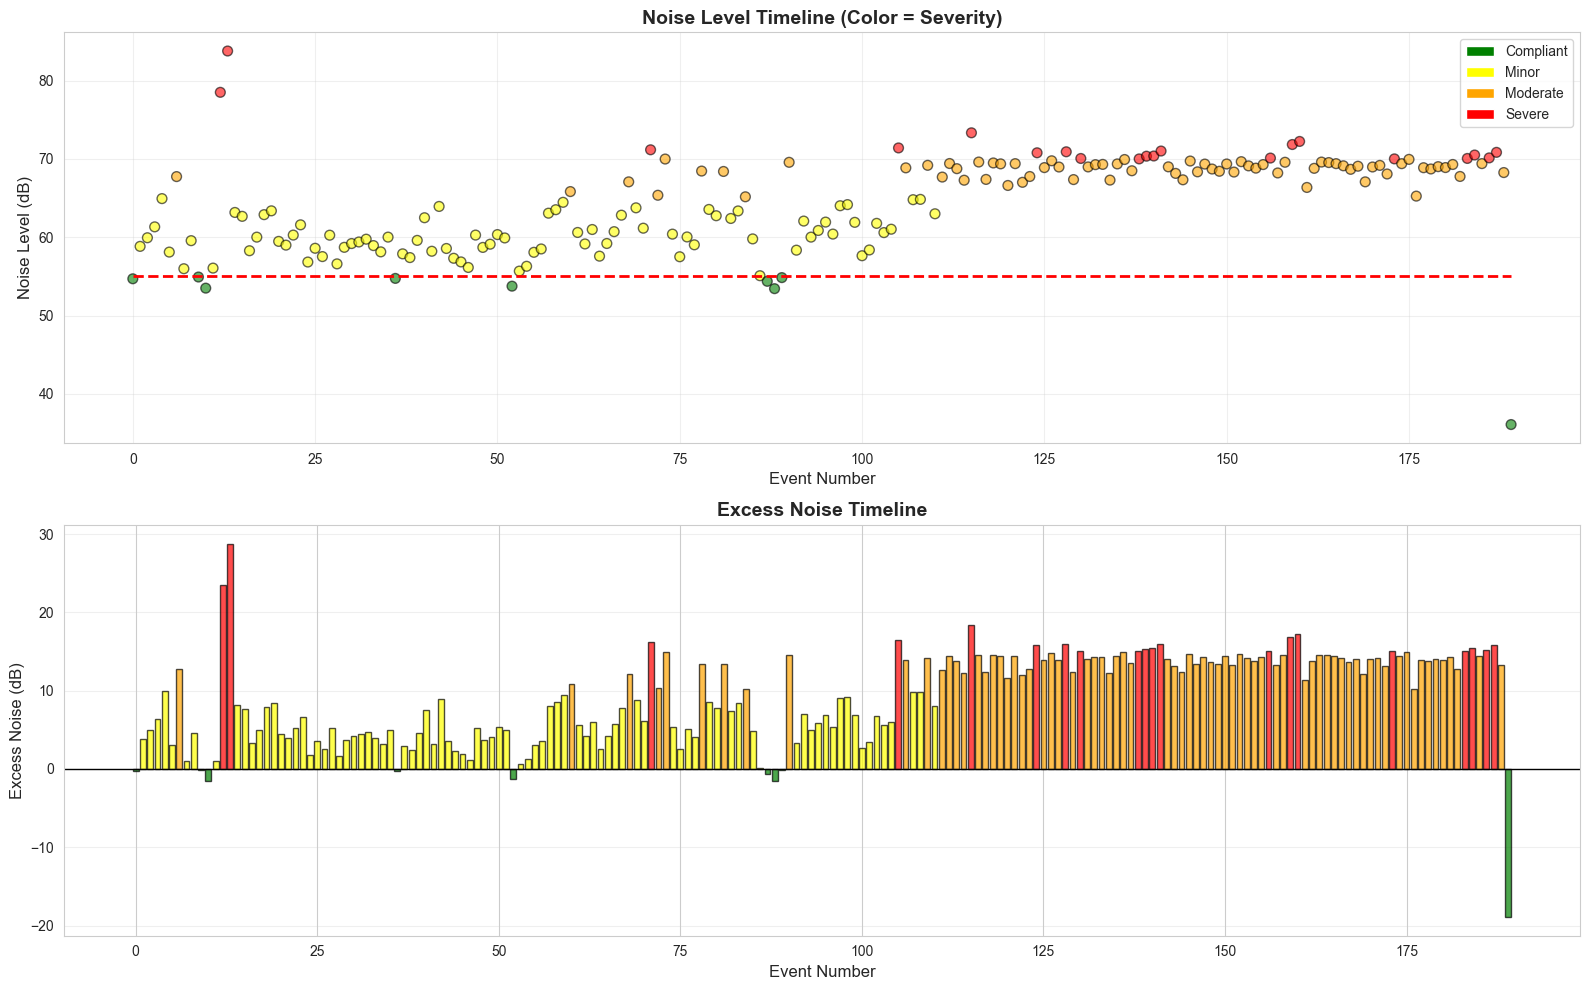

✅ Timeline visualization complete


In [33]:
# Create timeline visualization
if classified_events:
    # Extract data for timeline
    event_numbers = list(range(len(classified_events)))
    noise_levels = [e.noise_level_db for e in classified_events]
    ambient_limits = [e.ambient_limit_db for e in classified_events]
    severities = [e.severity for e in classified_events]
    
    # Create color map for severity
    severity_colors = {
        'compliant': 'green',
        'minor': 'yellow',
        'moderate': 'orange',
        'severe': 'red'
    }
    colors = [severity_colors.get(s, 'gray') for s in severities]
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # Timeline of noise levels
    ax1.scatter(event_numbers, noise_levels, c=colors, s=50, alpha=0.6, edgecolors='black')
    ax1.plot(event_numbers, ambient_limits, 'r--', linewidth=2, label='Ambient Limit')
    ax1.set_xlabel('Event Number', fontsize=12)
    ax1.set_ylabel('Noise Level (dB)', fontsize=12)
    ax1.set_title('Noise Level Timeline (Color = Severity)', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Create legend for severity colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='Compliant'),
        Patch(facecolor='yellow', label='Minor'),
        Patch(facecolor='orange', label='Moderate'),
        Patch(facecolor='red', label='Severe')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Excess noise over time
    excess_levels = [e.excess_db for e in classified_events]
    ax2.bar(event_numbers, excess_levels, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Event Number', fontsize=12)
    ax2.set_ylabel('Excess Noise (dB)', fontsize=12)
    ax2.set_title('Excess Noise Timeline', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Timeline visualization complete")
else:
    print("No events to visualize")

## 16. Generate Compliance Report

Create a formatted compliance report.

In [34]:
# Generate formatted compliance report
report_lines = []

report_lines.append("=" * 80)
report_lines.append("URBAN NOISE COMPLIANCE REPORT")
report_lines.append("=" * 80)
report_lines.append(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append(f"Zone: {CONFIG['default_zone'].value.upper()}")
report_lines.append(f"Total Events Analyzed: {len(classified_events)}")

report_lines.append(f"\n{'EXECUTIVE SUMMARY':-^80}")
report_lines.append(f"\nCompliance Rate: {compliant_events/total_events*100:.1f}%")
report_lines.append(f"Total Violations: {violation_events}")
report_lines.append(f"Severe Violations: {severity_counts.get('severe', 0)}")

report_lines.append(f"\n{'NOISE STATISTICS':-^80}")
avg_noise = np.mean([e.noise_level_db for e in classified_events])
max_noise = max([e.noise_level_db for e in classified_events])
report_lines.append(f"\nAverage Noise Level: {avg_noise:.1f} dB(A)")
report_lines.append(f"Maximum Noise Level: {max_noise:.1f} dB(A)")
report_lines.append(f"Ambient Limit: {classified_events[0].ambient_limit_db:.1f} dB(A)")

if violation_events > 0:
    avg_excess = np.mean([e.excess_db for e in classified_events if e.noise_exceeded])
    max_excess = max([e.excess_db for e in classified_events if e.noise_exceeded])
    report_lines.append(f"Average Excess (violations): {avg_excess:.1f} dB")
    report_lines.append(f"Maximum Excess: {max_excess:.1f} dB")

report_lines.append(f"\n{'TOP VIOLATIONS':-^80}")
if violation_type_counts:
    for v_type, count in sorted(violation_type_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        report_lines.append(f"  • {v_type}: {count} occurrences")
else:
    report_lines.append("  ✓ No violations detected")

report_lines.append(f"\n{'CONSTRUCTION ACTIVITY':-^80}")
construction_count = sum(1 for e in classified_events if e.is_construction_site)
report_lines.append(f"\nConstruction Sites Detected: {construction_count}")
report_lines.append(f"Percentage: {construction_count/total_events*100:.1f}%")

report_lines.append(f"\n{'RECOMMENDATIONS':-^80}")
if severe_violations:
    report_lines.append(f"\n⚠️  URGENT: {len(severe_violations)} severe violations require immediate attention")
if violation_events > 0:
    report_lines.append(f"\n• Reduce ambient noise levels in {violation_events} event(s)")
    if ViolationType.CONSTRUCTION_PROHIBITED.value in violation_type_counts:
        report_lines.append(f"• Restrict construction activities during prohibited hours")
    if ViolationType.HORN_PROHIBITED.value in violation_type_counts:
        report_lines.append(f"• Enforce horn usage restrictions")
else:
    report_lines.append("\n✓ All events are compliant with regulations")

report_lines.append(f"\n{'END OF REPORT':-^80}")
report_lines.append("=" * 80)

# Print report
report_text = "\n".join(report_lines)
print(report_text)

# Save report to file
report_file = Path(CONFIG['event_output_dir']) / f"compliance_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
report_file.parent.mkdir(parents=True, exist_ok=True)
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f"\n📄 Report saved to: {report_file}")

URBAN NOISE COMPLIANCE REPORT

Generated: 2025-11-02 01:40:37
Zone: RESIDENTIAL
Total Events Analyzed: 190

-------------------------------EXECUTIVE SUMMARY--------------------------------

Compliance Rate: 4.7%
Total Violations: 181
Severe Violations: 20

--------------------------------NOISE STATISTICS--------------------------------

Average Noise Level: 64.2 dB(A)
Maximum Noise Level: 83.8 dB(A)
Ambient Limit: 55.0 dB(A)
Average Excess (violations): 9.8 dB
Maximum Excess: 28.8 dB

---------------------------------TOP VIOLATIONS---------------------------------
  • ambient_exceeded: 181 occurrences

-----------------------------CONSTRUCTION ACTIVITY------------------------------

Construction Sites Detected: 91
Percentage: 47.9%

--------------------------------RECOMMENDATIONS---------------------------------

⚠️  URGENT: 20 severe violations require immediate attention

• Reduce ambient noise levels in 181 event(s)

---------------------------------END OF REPORT--------------------

## Summary

This notebook provides a complete integrated pipeline for urban noise classification and compliance monitoring:

### Key Features:
1. ✅ **Automated Processing**: Complete pipeline from raw media to classified events
2. ✅ **Multi-Modal Analysis**: Combines audio, video, and noise level data
3. ✅ **Regulatory Compliance**: Based on Indian Noise Pollution Rules
4. ✅ **Comprehensive Storage**: JSON, CSV, and summary reports
5. ✅ **Detailed Visualizations**: Charts, timelines, and distributions
6. ✅ **Flexible Configuration**: Easy to customize zones, thresholds, and parameters

### Outputs Generated:
- Event classifications with violation details
- Compliance reports and statistics
- Audio/video detection summaries
- Noise level analysis
- Severity assessments and recommendations

### Next Steps:
- Adjust `CONFIG` parameters for your specific use case
- Process different zones by changing `default_zone`
- Fine-tune confidence thresholds for better detection
- Export results for further analysis or reporting